# Momentum

The momentum factor assumes that previous winners will continue to outperform while previous losers will continue to underperform. Despite its long-documented profitability, momentum does not have a widely accepted risk-based explanation. A common interpretation is that investors initially underreact to new information, causing prices to adjust gradually over time. Because momentum traders buy assets that have recently increased in value and sell assets that have recently declined, momentum is considered a positive-feedback trading strategy. As a result, it is one of the strategies in which arbitrage activity may become destabilizing when trading becomes excessively crowded.

# Comomentum

Measuring arbitrage activity in financial markets is an important concern for trading strategies. When many investors and funds simultaneously implement momentum strategies, their trades can generate price movements that are not fully explained by fundamental information or common risk factors. This behaviour may lead to overreaction, causing prices to deviate from their fundamental values and eventually revert.

Comomentum is a measure designed to capture arbitrage activity in momentum strategies. It measures the abnormal comovement among winner stocks and among loser stocks after controlling for common risk factors. The intuition is that when many momentum traders hold similar positions, their trading activity causes these stocks to move together more strongly than expected.

A key finding of the literature is that high comomentum is associated with crowded momentum trading, lower future momentum returns, higher volatility, and stronger return reversals. This result is particularly important because arbitrageurs are traditionally viewed as stabilizing market participants; however, in positive-feedback strategies such as momentum, excessive arbitrage activity can instead contribute to market instability.


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import os

# Data

US_Returns.csv: Weekly total stock returns (including reinvested dividends) in decimals.

US_live.csv: A dummy variable which indicates when a company was live (dummy = 1) and
when it was dead (dummy = 0).

FamaFrench.csv: Weekly factor returns of the three Fama-French factors, namely the
market excess return over the risk-free rate (Mkt-RF), the size factor (SMB) and the value
factor (HML). The risk-free rate (RF) is also given but it is not a separate factor. 



In [73]:
main_dir = project_root = os.path.dirname(os.getcwd())
data_dir = main_dir + "/data/processed/"


# Read data
#I make sure to use the correct columns
FamaFrench = pd.read_csv("../data/raw/FamaFrench.csv", usecols=["Date", "Mkt-RF", "SMB", "HML", "RF"])
#We convert the Date column to datetime format and set it as the index of the DataFrame
FamaFrench["Date"] = pd.to_datetime(FamaFrench["Date"], format="%Y%m%d")
FamaFrench.set_index("Date", inplace=True)
FamaFrenchSize = FamaFrench.shape

#I read the US_Dates.xlsx file and convert the Date column to datetime format
US_dates = pd.read_excel("../data/raw/US_Dates.xlsx",header = None)
US_dates.columns = ["Date"]
US_dates["Date"] = pd.to_datetime(US_dates["Date"], format="%Y%m%d")
US_datesSize = US_dates.shape

#I read the US_live.csv file
US_live = pd.read_csv("../data/raw/US_live.csv", header = None)
US_liveSize = US_live.shape
id_stock = np.arange(0, US_liveSize[1])
US_live = US_live.rename(columns = {US_live.columns[i]: id_stock[i] for i in range(len(US_live.columns))})

#I wont use the header of US_returns.csv, instead I will use the id_stock as column names
US_returns = pd.read_csv("../data/raw/US_Returns.csv", names = id_stock)
US_returnsSize = US_returns.shape

T, N = US_returns.shape

In [74]:
#Create a matrix to store the momentum values, initialized with NaN values
momentum = np.full((T, N), np.nan)

#Degfine the window and skip parameters for momentum calculation
#We will be looking back for 48 weeks, and we will skip the most recent 4 weeks
window = 48
skip = 4

#We will skip the first 4 weeks and save them in a variable called lagged
lagged= US_returns.shift(skip)
#We calculate the momentum using the rolling window
#We are using log returns to calculate the momentum
momentum = (np.log(lagged + 1)).rolling(window=window, min_periods=window).sum()

In [75]:
# Count valid returns for each date
# We are summing the number of non-NaN values for each row (date) in the momentum DataFrame
valid_counts = momentum.notna().sum(axis=1) 

#Define ranks for each date
# We are assigning ranks to the momentum values for each date, with the highest momentum getting rank 1 and the lowest getting rank N
ranks = momentum.rank(axis=1, ascending=False, method="first")

# Define the top and bottom deciles based on the ranks 
top_cutoff = np.ceil(valid_counts * 0.10).astype(int) 
bottom_cutoff = (valid_counts - top_cutoff + 1).astype(int)

top_decile_mask = ranks.le(top_cutoff, axis=0) & momentum.notna() 
bottom_decile_mask = ranks.ge(bottom_cutoff, axis=0) & momentum.notna()

top_decile = momentum.where(top_decile_mask)
bottom_decile = momentum.where(bottom_decile_mask)

In [76]:
# Debug row 1508 to understand the top/bottom decile split
row_idx = 1508
print(f"Row {row_idx} diagnostics:")
print(f"Valid momentum count: {valid_counts.iloc[row_idx]}")
print(f"Top cutoff: {top_cutoff.iloc[row_idx]}")
print(f"Bottom cutoff: {bottom_cutoff.iloc[row_idx]}")
print()

# Check which stocks have valid momentum in this row
valid_stocks = momentum.iloc[row_idx].dropna()
print(f"Number of stocks with valid momentum: {len(valid_stocks)}")
print()

# Check the ranks for this row
ranks_this_row = ranks.iloc[row_idx]
top_mask_this_row = top_decile_mask.iloc[row_idx]
bottom_mask_this_row = bottom_decile_mask.iloc[row_idx]

print(f"Stocks in top decile for row {row_idx}: {top_mask_this_row.sum()}")
print(f"Stocks in bottom decile for row {row_idx}: {bottom_mask_this_row.sum()}")
print()

# Show top and bottom momentum values for this row
print(f"Top decile values: {top_decile.iloc[row_idx].dropna().values[:5]}")
print(f"Bottom decile values: {bottom_decile.iloc[row_idx].dropna().values[:5]}")

Row 1508 diagnostics:
Valid momentum count: 1697
Top cutoff: 170
Bottom cutoff: 1528

Number of stocks with valid momentum: 1697

Stocks in top decile for row 1508: 170
Stocks in bottom decile for row 1508: 170

Top decile values: [0.60817575 0.51393359 0.65395436 0.42937709 0.52236016]
Bottom decile values: [-1.02372986 -0.91200933 -0.59389386 -0.91779661 -0.71348214]


The next step is to run a cross-sectional regression where we are going to regress the cross sectional momentum of the market (all live stocks) on the future returns.

There are some important observations for the following steps:
1-. We are using a cummulative log momentum, this will affect the interpretation of $\beta$. This will be return per units of log-momentum but it will be difficult to compare this result with following weeks if the momentum changes much, the solution would be to standardize momentum

2-. To do so, we will get z score, subtracting the mean dividing it by the variance, this will turn the $\beta$ into extra returns asociated to moving standard deviations in the cross sectional ranking


In [77]:
#We take the real number of valid observations for each date, which is the number of non-NaN values in the momentum DataFrame
valid_obs = momentum.notna().sum(axis=1)
#We calculate the mean and standard deviation of the momentum values for each date, ignoring NaN values
mean = momentum.sum(axis = 1 )  / valid_obs
std = np.sqrt(((momentum.sub(mean, axis=0))**2).sum(axis=1) / valid_obs)
#We standardize the momentum values by subtracting the mean and dividing by the standard deviation for each date
momentum_std = momentum.sub(mean, axis = 0).div(std, axis=0)

After standardizing the momentum values, we proceed to run a regression

Remember that there are some filters fro this procedure:

1- We will only consider momentum when the returns of the stocks one period after are not NaN

2- We will only consider momentum when there is one year of valid momentum data (i.e., at least 48 weeks without the 4 weeks skip of non-NaN values)

This filters are indeed rigid; we are excluding live companies that have missing data within the window. We calculate how many empty momentum observations we have and count how many of them were supposed to be active companies



In [78]:
# Count how many NaN observations are present.
momentum_nan = momentum.isna()
# Count how many times momentum is NaN while the company was "alive" according to US_live
mismatch = momentum_nan & (US_live == 1)
print(mismatch.sum().sum(), "NaN observations with live ticker")
print(momentum_nan.sum().sum(), "NaN observations in total")
print("Percentage of NaN observations with live ticker:", (mismatch.sum().sum() / momentum_nan.sum().sum()) * 100, "%")

961940 NaN observations with live ticker
9131281 NaN observations in total
Percentage of NaN observations with live ticker: 10.534556980559463 %


This result would not be a problem, so the filters can be assumed to be correct since only the 10 % of the NaN observations were supposed to have a valid value.

Now we proceed with the regression:


# OLS Regression Theory

OLS makes the following assumptions so the estimators are unbiassed and efficient.


The residuals of the regression have zero mean, or its expected value is zero. <br>
$
\mathbb{E} (\epsilon) = 0
$

The residuals are independent of x <br>
$
\mathbb{E}(\epsilon | X) = \mathbb{E}(\epsilon)
$

The residuals are normally distributed


In [ ]:
#Regression for just one observation
next_ret = US_returns.shift(-1)
next_live = US_live.shift(-1)

mask =  ((momentum_std.notna()) & (next_ret.notna()) & (next_live == 1))

x_valid  = momentum_std.where(mask)
y_valid = next_ret.where(mask)

x_mean = x_valid.mean(axis=1)
y_mean = y_valid.mean(axis=1)


x_dev = x_valid.sub(x_mean, axis=0)
y_dev = y_valid.sub(y_mean, axis=0)

num = (x_dev * y_dev).sum(axis=1)
div = (x_dev ** 2).sum(axis=1)



beta = num / div.where(div != 0, np.nan)  # Avoid division by zero
alpha = y_mean.sub(beta * x_mean, axis=0)

In [80]:
#We calculate the fitted values and residuals for the regression
fitted = x_valid.mul(beta, axis=0).add(alpha, axis=0)
residuals = y_valid.sub(fitted, axis=0)

In [ ]:
mean_by_week = residuals.mean(axis=1, skipna=True) #Calculate the mean of the residuals for each week, ignoring NaN values

3.222354632448625e-17


Media global: 5.624396089653108e-20
Desviación estándar: 0.04659772767804593


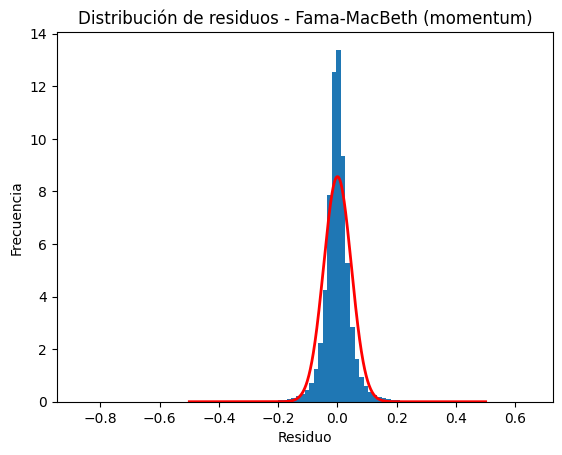

In [ ]:
all_residuals = residuals.values.flatten()
all_residuals = all_residuals[~np.isnan(all_residuals)]

x_normal = np.linspace(-.5, .5, 1000)
y_normal = stats.norm.pdf(x_normal, loc=all_residuals.mean(), scale=all_residuals.std())


print("Mean:", all_residuals.mean())
print("Standard deviation:", all_residuals.std())

plt.hist(all_residuals, bins=100, density=True)
plt.xlabel("Residals")
plt.ylabel("Density")
plt.title("Residuals ditribution")
plt.plot(x_normal, y_normal, 'r-', linewidth=2)
plt.show()